### Hybrid Siamese BiLSTM Resume-Job Regression

- bidirectional LSTM instead of one-direction final-state LSTM
- mean pooling + max pooling over sequence outputs instead of only the final hidden state
- lexical overlap features added to the pair representation
- structured features appended to the regression head
- `SmoothL1Loss` + `AdamW` + `ReduceLROnPlateau`
- optional multi-seed training to estimate the model's ceiling more fairly


In [1]:
# imports

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader

from siamese_lstm import (
    HybridSiameseBiLSTMRegressor,
    ResumeJobDataset,
    build_vocab,
    collate_batch,
    fit_model,
    load_pretrained_embeddings,
    predict,
    regression_metrics,
    set_seed,
    tokenize_frame,
)

In [ ]:
# configuration

DATA_PATH = Path('resume_data_cleaned.csv')
EMBED_PATH = Path('dan + predefined embeddings/embeddings/dolma_300_relativised.txt')

PRIMARY_SEED = 42
SEED_SWEEP = [42, 52, 62]
RUN_SEED_SWEEP = True

TEST_SIZE = 0.2
VAL_SIZE = 0.15

MAX_VOCAB = 35000
MIN_FREQ = 1
MAX_RESUME_LEN = 220
MAX_JOB_LEN = 96
EMBED_DIM = 300
HIDDEN_SIZE = 128
DROPOUT = 0.35
BATCH_SIZE = 64
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
EPOCHS = 24
PATIENCE = 6
FREEZE_EMBEDDINGS = False

STRUCT_COLS = [
    'num_skills',
    'num_degrees',
    'num_positions',
    'experience_years',
    'age_min',
    'age_max',
    'skill_jaccard',
]

BASELINE_RESULTS = {
    '1. combined_text tfidf': {'R2': 0.4938, 'MSE': 0.0140},
    '2. separate tfidf': {'R2': 0.4792, 'MSE': 0.0144},
    '3. structured only': {'R2': 0.0939, 'MSE': 0.0251},
    '4. hybrid (tfidf+struct)': {'R2': 0.5256, 'MSE': 0.0131},
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
print(f'device: {device}')

device: cpu


In [3]:
# load data once and keep the same split logic as the previous notebooks

df = pd.read_csv(DATA_PATH)
for col in ['resume_text', 'job_text', 'combined_text']:
    df[col] = df[col].fillna('')

for col in STRUCT_COLS:
    df[col] = df[col].fillna(df[col].median())

train_df, test_df = train_test_split(df, test_size=TEST_SIZE, random_state=PRIMARY_SEED)
train_df, val_df = train_test_split(train_df, test_size=VAL_SIZE, random_state=PRIMARY_SEED)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_resume_tokens, train_job_tokens = tokenize_frame(train_df)
vocab = build_vocab(train_resume_tokens + train_job_tokens, max_vocab_size=MAX_VOCAB, min_freq=MIN_FREQ)
embedding_matrix, coverage = load_pretrained_embeddings(EMBED_PATH, vocab, EMBED_DIM)

resume_lengths = np.array([len(tokens) for tokens in train_resume_tokens])
job_lengths = np.array([len(tokens) for tokens in train_job_tokens])

print(f'rows: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}')
print(f'vocab size: {len(vocab)}')
print(f'pretrained coverage: {coverage:.2%}')
print(f'resume median/p95 tokens: {np.median(resume_lengths):.0f} / {np.percentile(resume_lengths, 95):.0f}')
print(f'job median/p95 tokens: {np.median(job_lengths):.0f} / {np.percentile(job_lengths, 95):.0f}')

rows: train=6489, val=1146, test=1909
vocab size: 3904
pretrained coverage: 64.02%
resume median/p95 tokens: 82 / 168
job median/p95 tokens: 21 / 33


In [4]:
# dataset factory

def make_dataloaders(batch_size=BATCH_SIZE):
    train_dataset = ResumeJobDataset(
        train_df,
        vocab=vocab,
        max_resume_len=MAX_RESUME_LEN,
        max_job_len=MAX_JOB_LEN,
        struct_cols=STRUCT_COLS,
    )
    val_dataset = ResumeJobDataset(
        val_df,
        vocab=vocab,
        max_resume_len=MAX_RESUME_LEN,
        max_job_len=MAX_JOB_LEN,
        struct_cols=STRUCT_COLS,
    )
    test_dataset = ResumeJobDataset(
        test_df,
        vocab=vocab,
        max_resume_len=MAX_RESUME_LEN,
        max_job_len=MAX_JOB_LEN,
        struct_cols=STRUCT_COLS,
    )
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_batch)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_batch)
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_dataloaders()
sample_batch = next(iter(train_loader))
for key, value in sample_batch.items():
    print(f'{key}: {tuple(value.shape)}')

resume_ids: (64, 220)
resume_len: (64,)
job_ids: (64, 96)
job_len: (64,)
lexical: (64, 5)
target: (64,)
struct: (64, 7)


In [5]:
# one full training run

def run_one_seed(seed):
    set_seed(seed)
    train_loader, val_loader, test_loader = make_dataloaders()

    model = HybridSiameseBiLSTMRegressor(
        vocab_size=len(vocab),
        embedding_dim=EMBED_DIM,
        hidden_size=HIDDEN_SIZE,
        dropout=DROPOUT,
        embedding_matrix=embedding_matrix,
        freeze_embeddings=FREEZE_EMBEDDINGS,
        struct_dim=len(STRUCT_COLS),
        lexical_dim=5,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=2,
        min_lr=1e-5,
    )
    criterion = nn.SmoothL1Loss(beta=0.05)
    checkpoint_path = ARTIFACT_DIR / f'hybrid_seed_{seed}.pt'

    history, best_epoch, checkpoint_path = fit_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        epochs=EPOCHS,
        patience=PATIENCE,
        checkpoint_path=checkpoint_path,
        scheduler=scheduler,
    )

    history_df = pd.DataFrame(history)
    y_val, val_pred = predict(model, val_loader, device)
    y_test, test_pred = predict(model, test_loader, device)

    val_metrics = regression_metrics(y_val, val_pred)
    test_metrics = regression_metrics(y_test, test_pred)

    return {
        'seed': seed,
        'model': model,
        'history_df': history_df,
        'best_epoch': best_epoch,
        'checkpoint_path': checkpoint_path,
        'y_val': y_val,
        'val_pred': val_pred,
        'val_metrics': val_metrics,
        'y_test': y_test,
        'test_pred': test_pred,
        'test_metrics': test_metrics,
    }

In [6]:
# run either one seed or a small sweep, then keep the best validation run

seeds_to_run = SEED_SWEEP if RUN_SEED_SWEEP else [PRIMARY_SEED]
runs = []
for seed in seeds_to_run:
    print(f'\n=== training seed {seed} ===')
    run = run_one_seed(seed)
    runs.append(run)
    print(f"best epoch: {run['best_epoch']}")
    print(f"val R2:  {run['val_metrics']['r2']:.4f}")
    print(f"test R2: {run['test_metrics']['r2']:.4f}")

seed_summary = pd.DataFrame([
    {
        'seed': run['seed'],
        'best_epoch': run['best_epoch'],
        'val_R2': run['val_metrics']['r2'],
        'val_MSE': run['val_metrics']['mse'],
        'test_R2': run['test_metrics']['r2'],
        'test_MSE': run['test_metrics']['mse'],
        'test_MAE': run['test_metrics']['mae'],
    }
    for run in runs
]).sort_values('val_R2', ascending=False).reset_index(drop=True)

best_run = max(runs, key=lambda run: run['val_metrics']['r2'])
history_df = best_run['history_df']
y_test = best_run['y_test']
y_pred = best_run['test_pred']
test_metrics = best_run['test_metrics']

display(seed_summary.round(4))
print(f"selected seed: {best_run['seed']}")
print(f"selected checkpoint: {best_run['checkpoint_path']}")


=== training seed 42 ===
best epoch: 17
val R2:  0.6360
test R2: 0.6679

=== training seed 52 ===
best epoch: 6
val R2:  0.5386
test R2: 0.5837

=== training seed 62 ===
best epoch: 24
val R2:  0.6302
test R2: 0.6551


,seed,best_epoch,val_R2,val_MSE,test_R2,test_MSE,test_MAE
0,42,17,0.6360,0.0103,0.6679,0.0092,0.0745
1,62,24,0.6302,0.0105,0.6551,0.0095,0.0757
2,52,6,0.5386,0.0131,0.5837,0.0115,0.0842


selected seed: 42
selected checkpoint: artifacts\hybrid_siamese_bilstm\hybrid_seed_42.pt


In [7]:
# compare against prior baselines

results = dict(BASELINE_RESULTS)
results['5. hybrid siamese bilstm'] = {
    'R2': test_metrics['r2'],
    'MSE': test_metrics['mse'],
}
results_df = pd.DataFrame(results).T.sort_values('R2')

print(pd.Series({
    'selected_seed': best_run['seed'],
    'R2': test_metrics['r2'],
    'MSE': test_metrics['mse'],
    'MAE': test_metrics['mae'],
}).to_string())
display(results_df.round(4))

selected_seed    42.000000
R2                0.667888
MSE               0.009184
MAE               0.074484


,R2,MSE
3. structured only,0.0939,0.0251
2. separate tfidf,0.4792,0.0144
1. combined_text tfidf,0.4938,0.0140
4. hybrid (tfidf+struct),0.5256,0.0131
5. hybrid siamese bilstm,0.6679,0.0092


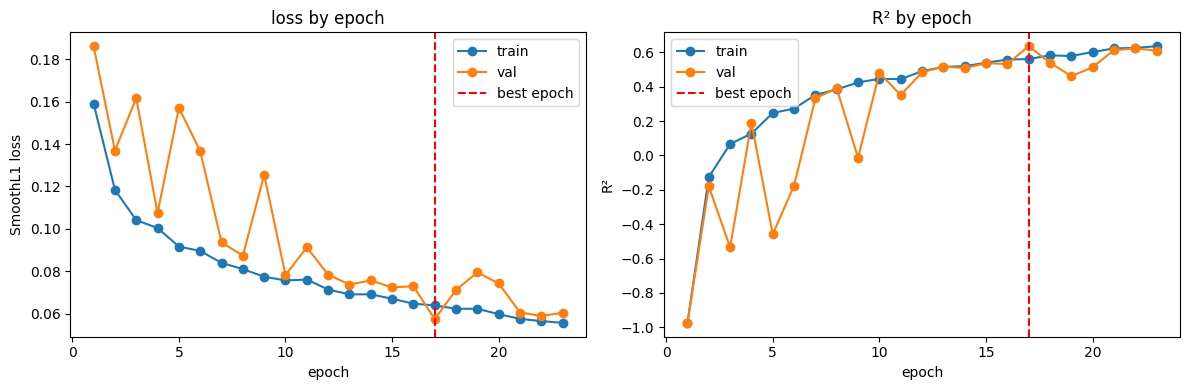

In [8]:
# training curves for the selected run

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o', label='train')
axes[0].plot(history_df['epoch'], history_df['val_loss'], marker='o', label='val')
axes[0].axvline(best_run['best_epoch'], color='red', linestyle='--', label='best epoch')
axes[0].set_title('loss by epoch')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('SmoothL1 loss')
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['train_r2'], marker='o', label='train')
axes[1].plot(history_df['epoch'], history_df['val_r2'], marker='o', label='val')
axes[1].axvline(best_run['best_epoch'], color='red', linestyle='--', label='best epoch')
axes[1].set_title('R² by epoch')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('R²')
axes[1].legend()

plt.tight_layout()
plt.show()

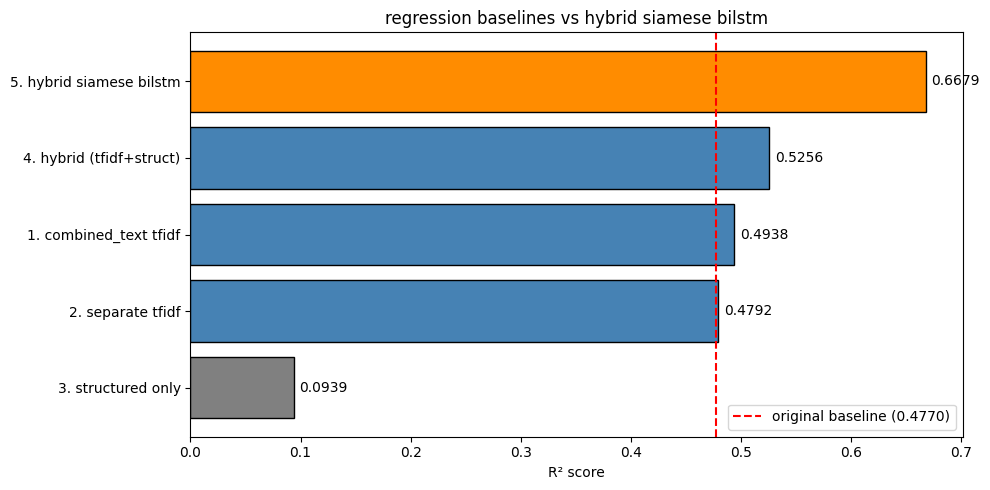

In [9]:
# comparison plot in the same spirit as regression_cleaned.ipynb

fig, ax = plt.subplots(figsize=(10, 5))
labels = list(results_df.index)
r2_vals = results_df['R2'].values
colors = ['gray', 'steelblue', 'steelblue', 'steelblue', 'darkorange']

bars = ax.barh(labels, r2_vals, color=colors, edgecolor='black')
ax.axvline(x=0.4770, color='red', linestyle='--', label='original baseline (0.4770)')
ax.set_xlabel('R² score')
ax.set_title('regression baselines vs hybrid siamese bilstm')
ax.legend()

for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2, f'{val:.4f}', va='center')

plt.tight_layout()
plt.show()

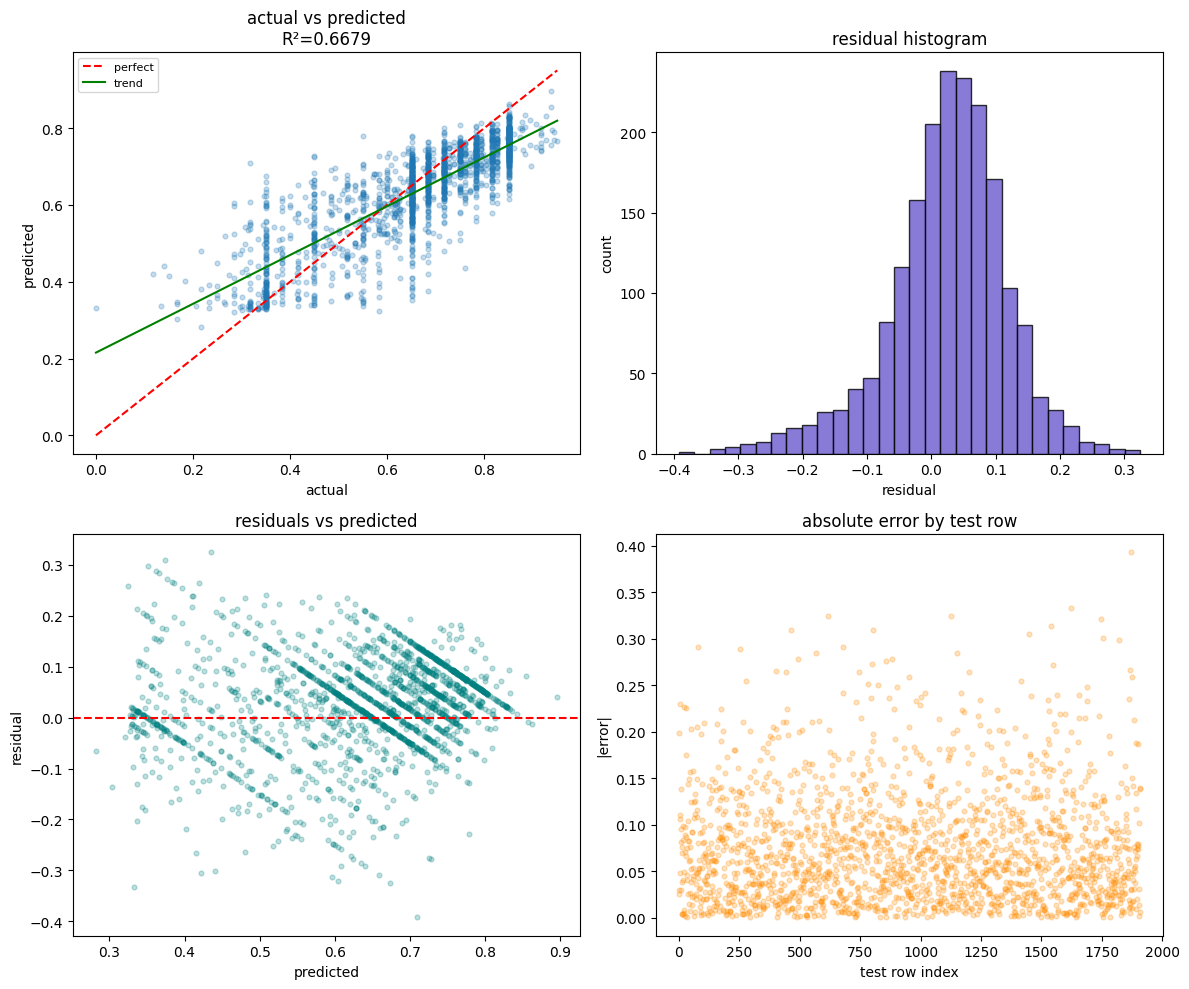

In [10]:
# prediction diagnostics

residuals = y_test - y_pred
m, b = np.polyfit(y_test, y_pred, 1)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(y_test, y_pred, alpha=0.25, s=12)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='perfect')
axes[0, 0].plot([y_test.min(), y_test.max()], [m * y_test.min() + b, m * y_test.max() + b], 'g-', label='trend')
axes[0, 0].set_title(f'actual vs predicted\nR²={test_metrics["r2"]:.4f}')
axes[0, 0].set_xlabel('actual')
axes[0, 0].set_ylabel('predicted')
axes[0, 0].legend(fontsize=8)

axes[0, 1].hist(residuals, bins=30, edgecolor='black', color='slateblue', alpha=0.8)
axes[0, 1].set_title('residual histogram')
axes[0, 1].set_xlabel('residual')
axes[0, 1].set_ylabel('count')

axes[1, 0].scatter(y_pred, residuals, alpha=0.25, s=12, color='teal')
axes[1, 0].axhline(0.0, color='red', linestyle='--')
axes[1, 0].set_title('residuals vs predicted')
axes[1, 0].set_xlabel('predicted')
axes[1, 0].set_ylabel('residual')

axes[1, 1].scatter(np.arange(len(residuals)), np.abs(residuals), alpha=0.25, s=12, color='darkorange')
axes[1, 1].set_title('absolute error by test row')
axes[1, 1].set_xlabel('test row index')
axes[1, 1].set_ylabel('|error|')

plt.tight_layout()
plt.show()

In [11]:
# score-bin slices and examples

analysis_df = test_df[['resume_text', 'job_text', 'matched_score']].copy()
analysis_df['predicted_score'] = y_pred
analysis_df['residual'] = analysis_df['matched_score'] - analysis_df['predicted_score']
analysis_df['abs_error'] = analysis_df['residual'].abs()

analysis_df['score_bin'] = pd.cut(
    analysis_df['matched_score'],
    bins=[-0.001, 0.4, 0.7, 1.001],
    labels=['low (<=0.4)', 'mid (0.4-0.7)', 'high (>0.7)'],
)

bin_summary = analysis_df.groupby('score_bin', observed=False).agg(
    rows=('matched_score', 'size'),
    mean_actual=('matched_score', 'mean'),
    mean_pred=('predicted_score', 'mean'),
    mae=('abs_error', 'mean'),
    mse=('residual', lambda s: np.mean(np.square(s))),
)
display(bin_summary.round(4))

best_examples = analysis_df.nsmallest(5, 'abs_error')[['matched_score', 'predicted_score', 'abs_error', 'resume_text', 'job_text']]
worst_examples = analysis_df.nlargest(5, 'abs_error')[['matched_score', 'predicted_score', 'abs_error', 'resume_text', 'job_text']]

print('best predicted examples:')
display(best_examples)
print('worst predicted examples:')
display(worst_examples)

,rows,mean_actual,mean_pred,mae,mse
score_bin,,,,,
low (<=0.4),230,0.3302,0.4276,0.1007,0.0185
mid (0.4-0.7),812,0.6016,0.5940,0.0653,0.0075
high (>0.7),867,0.7989,0.7259,0.0761,0.0083


best predicted examples:


,matched_score,predicted_score,abs_error,resume_text,job_text
1498,0.550000,0.550062,0.000062,gis lighting designs using visual professional...,business development executive bachelor/honors...
35,0.493333,0.493182,0.000152,an avid data analyst looking to step into the ...,business development executive bachelor/honors...
406,0.813333,0.813133,0.000200,innovative and enthusiastic computer science e...,intern (generative ai engineering - 2d/3d imag...
1782,0.350000,0.350254,0.000254,i am a fresher who is looking to work as a sof...,manager- human resource management (hrm) maste...
937,0.650000,0.650289,0.000289,hard working recent graduate intending a part ...,project coordinator (civil) •bachelor of busin...


worst predicted examples:


,matched_score,predicted_score,abs_error,resume_text,job_text
1870,0.316667,0.709177,0.392510,to obtain a rewarding position in a field wher...,"full stack developer (python,react js) bachelo..."
1624,0.000000,0.332375,0.332375,"fresher with excellent communication, good ana...",head of internal control & compliance (icc) - ...
618,0.760000,0.435561,0.324439,computer repair technician ifixit pro tech too...,mechanical engineer bachelor of science (bsc) ...
1127,0.350000,0.673981,0.323981,accounts receivable professional sales softwar...,intern (generative ai engineering - 2d/3d imag...
1745,0.283333,0.604758,0.321425,"cad packages (solidworks, autodesk inventor, a...",data science engineer bachelor of science (bsc...
